# AGORA Project Delta - MODIS Dust Analysis

## Case study: Dust intrusion - March 2026

<a href="https://colab.research.google.com/github/jrobrien91/agora2026-dust/blob/main/notebooks/modis-dust.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![eumet-sat](../images/Eumetsat_View_2026-03-04T1200.png)

## Imports

**NOTE**
If Running on Google Colab, you will need to uncomment the following lines to
install required packages into the environment. 

In [ ]:
#!pip install cartopy
#!pip install pyhdf
#!pip install cmweather

In [ ]:
# Uncomment if running on CoLab
##import pathlib
##from pathlib import Path
##import gdown

##DATA_LINK = "1HMO56nvjmkGyhDYkKPkj8Fd0iET81ved"
##CREATE_BASE = pathlib.Path("./sample_data")
##CREATE_BASE.mkdir(parents=True, exist_ok=True)
##gdown.download(id=DATA_LINK, output=str(CREATE_BASE / "modis.tar.gz"), quiet=False)

In [ ]:
# Uncomment if running on CoLab
##!gunzip -f ./sample_data/modis.tar.gz
##!tar -xvf ./sample_data/modis.tar

In [367]:
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import cmweather
from pyhdf.SD import SD, SDC

## Basemap Creation 

Helpful to figure out where in the world we are focusing on first!

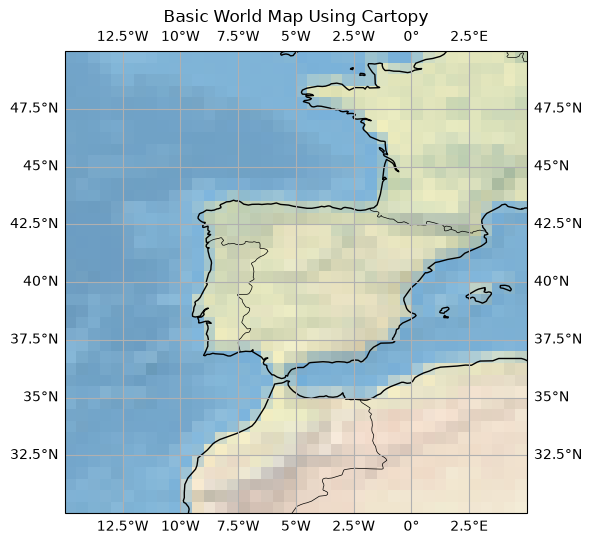

In [383]:
# Create a figure layout with a specific map projection
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add basic map features
ax.coastlines()
ax.stock_img()  # Adds a basic color topography background
ax.gridlines(draw_labels=True)  # Add gridlines with labels
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.set_xlim(-15, 5)
ax.set_ylim(30, 50)

plt.title('Basic World Map Using Cartopy')
plt.show()

## TERRA-MODIS

[MODIS Level-3 Daily Global products](https://atmosphere-imager.gsfc.nasa.gov/products/daily) is used within this analysis. 

Data were ordered through the [LAADS DAAC](https://ladsweb.modaps.eosdis.nasa.gov/search/order/2/MOD08_D3--61/2026-03-02..2026-03-04/DB/-12.8,44.7,4.8,33.3) and a NASA EarthData login is required. 

More information on the MODIS Atmosphere L3 Gridded Product can be found [here](https://atmosphere-imager.gsfc.nasa.gov/sites/default/files/ModAtmo/L3_ATBD_C6_C61_2019_02_20.pdf)

In [ ]:
terra_files = sorted(glob.glob("../sample_data/modis/terra/*.hdf"))

In [370]:
terra_files

['../data/modis/terra/MOD08_D3.A2026061.061.2026062084756.hdf',
 '../data/modis/terra/MOD08_D3.A2026062.061.2026063084523.hdf',
 '../data/modis/terra/MOD08_D3.A2026063.061.2026064134037.hdf']

In [ ]:
list_datasets(terra_files[0])

In [372]:
def read_terra_modis(hdf_file, 
                     lat_min=34, 
                     lat_max=46, 
                     lon_min=-12, 
                     lon_max=5):
    def read_sds(hdf, varname):
        sds = hdf.select(varname)
        data = sds[:].astype(float)
        attrs = sds.attributes()

        fill_value = attrs.get("_FillValue", None)
        valid_range = attrs.get("valid_range", None)
        scale_factor = attrs.get("scale_factor", 1.0)
        add_offset = attrs.get("add_offset", 0.0)

        if fill_value is not None:
            data[data == fill_value] = np.nan

        if valid_range is not None:
            data[(data < valid_range[0]) | (data > valid_range[1])] = np.nan

        data = (data - add_offset) * scale_factor

        return data

    hdf = SD(hdf_file, SDC.READ)

    lat = read_sds(hdf, "YDim")
    lon = read_sds(hdf, "XDim")
    deep_blue_levels = read_sds(hdf, "Deep_Blue_Aerosol_Optical_Depth_Land_Micron_Levels")
    
    deep_blue_aod_land_550 = read_sds(hdf, "Deep_Blue_Aerosol_Optical_Depth_550_Land_Mean")
    cth_day_mean = read_sds(hdf, "Cloud_Top_Height_Day_Mean")
    deep_blue_angstrom_land = read_sds(hdf, "Deep_Blue_Angstrom_Exponent_Land_Mean")
    deep_blue_ssa_land = read_sds(hdf, "Deep_Blue_Single_Scattering_Albedo_Land_Mean")
    deep_blue_aod = read_sds(hdf, "Deep_Blue_Aerosol_Optical_Depth_Land_Mean")
    cloud_fraction = read_sds(hdf, "Cloud_Fraction_Day_Mean")
    
    ds = xr.Dataset(
        data_vars={
            "deep_blue_aod_550": (("latitude", "longitude"), deep_blue_aod_land_550),
            "cloud_top_height" : (("latitude", "longitude"), cth_day_mean),
            "deep_blue_angstrom": (("latitude", "longitude"), deep_blue_angstrom_land),
            "deep_blue_ssa": (("wavelength", "latitude", "longitude"), deep_blue_ssa_land),
            "deep_blue_aod": (("wavelength", "latitude", "longitude"), deep_blue_aod),
            "cloud_fraction": (("latitude", "longitude"), cloud_fraction),
        },
        coords={
            "latitude": (lat),
            "longitude": (lon),
            "wavelength": (deep_blue_levels),
        },
        attrs={
            "source_file": hdf_file,
        }
)

    return ds

In [373]:
terra_aod_a = read_terra_modis(terra_files[1])
terra_aod_b = read_terra_modis(terra_files[2])

In [374]:
terra_aod_b

<xarray.Dataset> Size: 5MB
Dimensions:             (latitude: 180, longitude: 360, wavelength: 3)
Coordinates:
  * latitude            (latitude) float64 1kB 89.5 88.5 87.5 ... -88.5 -89.5
  * longitude           (longitude) float64 3kB -179.5 -178.5 ... 178.5 179.5
  * wavelength          (wavelength) float64 24B 0.412 0.47 0.66
Data variables:
    deep_blue_aod_550   (latitude, longitude) float64 518kB nan nan ... nan nan
    cloud_top_height    (latitude, longitude) float64 518kB nan nan ... nan nan
    deep_blue_angstrom  (latitude, longitude) float64 518kB nan nan ... nan nan
    deep_blue_ssa       (wavelength, latitude, longitude) float64 2MB nan ......
    deep_blue_aod       (wavelength, latitude, longitude) float64 2MB nan ......
    cloud_fraction      (latitude, longitude) float64 518kB nan nan ... 0.0 0.0
Attributes:
    source_file:  ../data/modis/terra/MOD08_D3.A2026063.061.2026064134037.hdf

/var/folders/7q/czgy7g_j3fb7jw3256f37wrw0000gq/T/ipykernel_31308/3475559743.py:47: UserWarning: Adding colorbar to a different Figure <Figure size 1800x800 with 3 Axes> than <Figure size 1800x800 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


Text(0.5, 0.98, 'MODIS Terra Deep Blue AOD at 550nm')

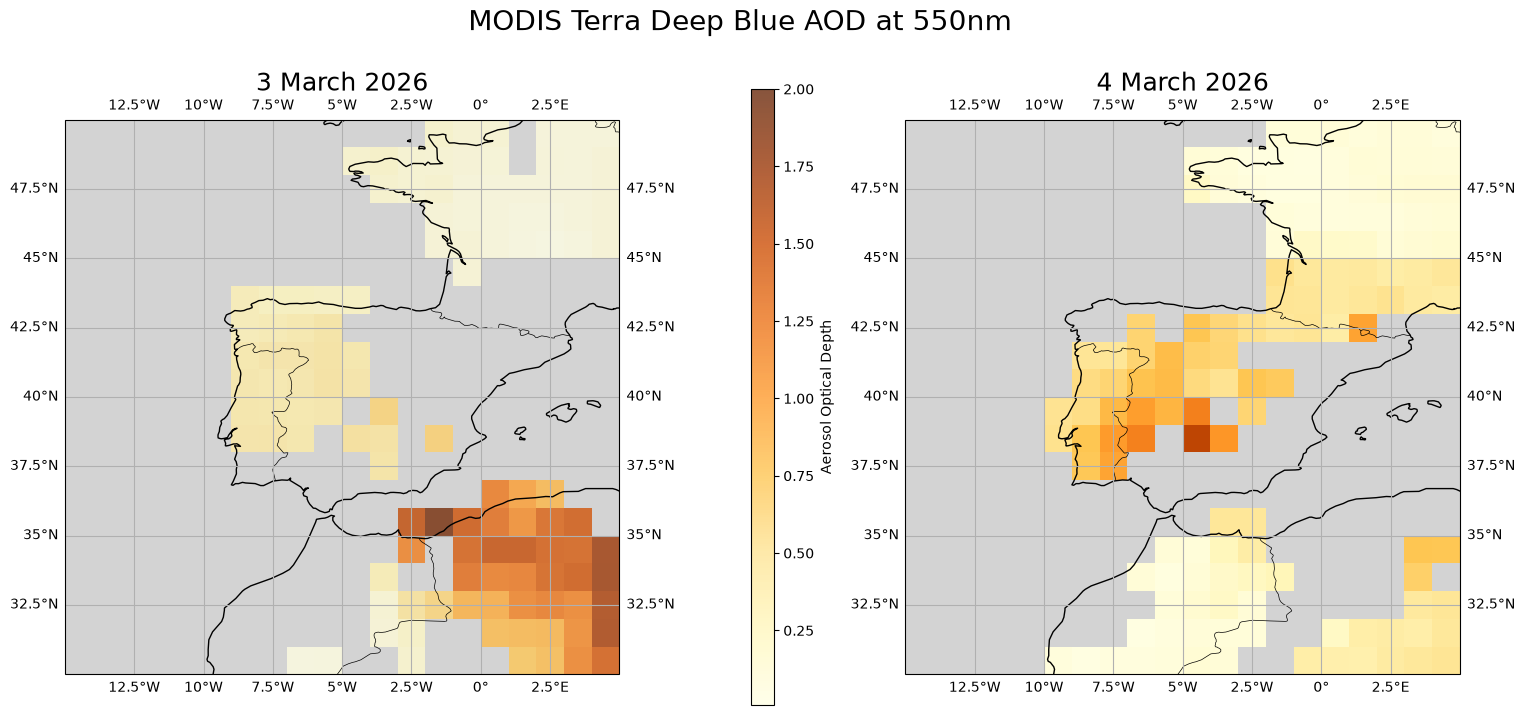

In [376]:
fig2 = plt.figure(figsize=(18, 8))

bin_edges = [0.0, 0.1, 0.3, 0.6, 1.5, 5.0]
cmap = plt.get_cmap("YlOrBr")
norm = colors.BoundaryNorm(bin_edges, ncolors=cmap.N)

gs = fig2.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 0.04, 1],
    wspace=0.35
)

axarr = fig2.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
cax = fig2.add_subplot(gs[0, 1])   # colorbar axis in the middle
axarr2 = fig2.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

m = terra_aod_a['deep_blue_aod_550'].transpose("longitude", "latitude").plot(transform=ccrs.PlateCarree(), 
                                                                             ax=axarr,
                                                                             x="longitude",
                                                                             add_colorbar=False, 
                                                                             alpha=0.78,
                                                                             cmap=cmap,
                                                                             vmax=2.0
                                                                             )
mappables.append(m)

# Add basic map features
axarr.coastlines()
#ax.stock_img()  # Adds a basic color topography background
axarr.gridlines(draw_labels=True)  # Add gridlines with labels
axarr.add_feature(cfeature.BORDERS, linewidth=0.5)
axarr.set_xlim(-15, 5)
axarr.set_ylim(30, 50)
axarr.set_facecolor("lightgray")
axarr.set_title("3 March 2026", fontsize=18)

n = terra_aod_b['deep_blue_aod_550'].transpose("longitude", "latitude").plot(transform=ccrs.PlateCarree(), 
                                                                             ax=axarr2,
                                                                             x="longitude",
                                                                             add_colorbar=False,
                                                                             vmax=2.0,
                                                                             cmap=cmap,
                                                                             )
mappables.append(n)

cbar = fig.colorbar(
    m,
    cax=cax,
    orientation="vertical",
)

cbar.set_label("Aerosol Optical Depth")

# Add basic map features
axarr2.coastlines()
#ax.stock_img()  # Adds a basic color topography background
axarr2.gridlines(draw_labels=True)  # Add gridlines with labels
axarr2.add_feature(cfeature.BORDERS, linewidth=0.5)
axarr2.set_xlim(-15, 5)
axarr2.set_ylim(30, 50)
axarr2.set_facecolor("lightgray")
axarr2.set_title("4 March 2026", fontsize=18)

plt.suptitle('MODIS Terra Deep Blue AOD at 550nm', fontsize=20)

/var/folders/7q/czgy7g_j3fb7jw3256f37wrw0000gq/T/ipykernel_31308/843549551.py:43: UserWarning: Adding colorbar to a different Figure <Figure size 1800x800 with 3 Axes> than <Figure size 1800x800 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


Text(0.5, 0.98, 'MODIS Terra Deep Blue Angstrom Exponent')

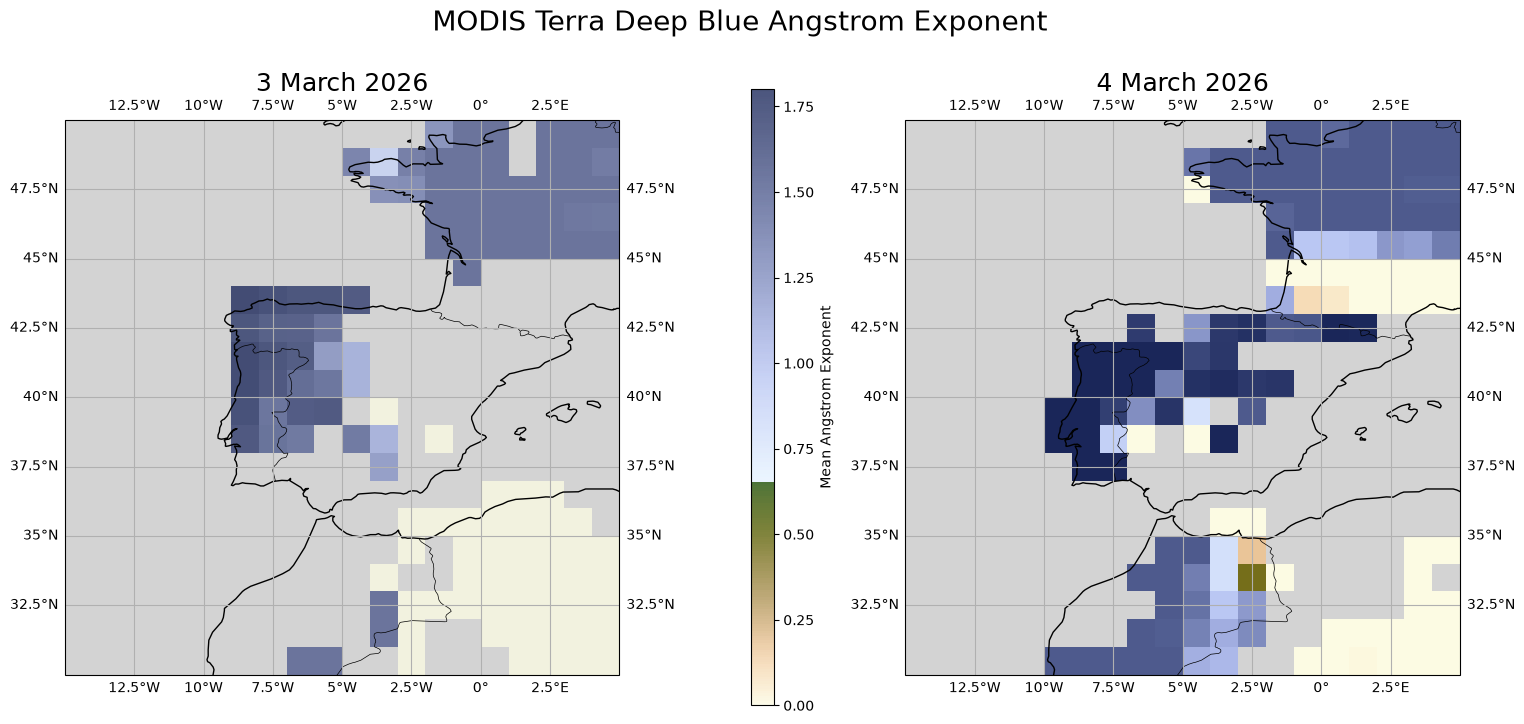

In [377]:
fig2 = plt.figure(figsize=(18, 8))

cmap = plt.get_cmap("CM_depol_r")

gs = fig2.add_gridspec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 0.04, 1],
    wspace=0.35
)

axarr = fig2.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
cax = fig2.add_subplot(gs[0, 1])   # colorbar axis in the middle
axarr2 = fig2.add_subplot(gs[0, 2], projection=ccrs.PlateCarree())

m = terra_aod_a['deep_blue_angstrom'].transpose("longitude", "latitude").plot(transform=ccrs.PlateCarree(), 
                                                                             ax=axarr,
                                                                             x="longitude",
                                                                             add_colorbar=False, 
                                                                             alpha=0.78,
                                                                             cmap=cmap,
                                                                             )
mappables.append(m)

# Add basic map features
axarr.coastlines()
#ax.stock_img()  # Adds a basic color topography background
axarr.gridlines(draw_labels=True)  # Add gridlines with labels
axarr.add_feature(cfeature.BORDERS, linewidth=0.5)
axarr.set_xlim(-15, 5)
axarr.set_ylim(30, 50)
axarr.set_facecolor("lightgray")
axarr.set_title("3 March 2026", fontsize=18)

n = terra_aod_b['deep_blue_angstrom'].transpose("longitude", "latitude").plot(transform=ccrs.PlateCarree(), 
                                                                             ax=axarr2,
                                                                             x="longitude",
                                                                             add_colorbar=False,
                                                                             cmap=cmap,
                                                                             )
mappables.append(n)

cbar = fig.colorbar(
    m,
    cax=cax,
    orientation="vertical",
)

cbar.set_label("Mean Angstrom Exponent")

# Add basic map features
axarr2.coastlines()
#ax.stock_img()  # Adds a basic color topography background
axarr2.gridlines(draw_labels=True)  # Add gridlines with labels
axarr2.add_feature(cfeature.BORDERS, linewidth=0.5)
axarr2.set_xlim(-15, 5)
axarr2.set_ylim(30, 50)
axarr2.set_facecolor("lightgray")
axarr2.set_title("4 March 2026", fontsize=18)

plt.suptitle('MODIS Terra Deep Blue Angstrom Exponent', fontsize=20)

## MODIS-Aqua 3km files

In [378]:
def read_modis_region(hdf_file, 
                      aod_variable, 
                      lat_min=34, 
                      lat_max=46, 
                      lon_min=-12, 
                      lon_max=5):
    def read_sds(hdf, varname):
        sds = hdf.select(varname)
        data = sds[:].astype(float)
        attrs = sds.attributes()

        fill_value = attrs.get("_FillValue", None)
        valid_range = attrs.get("valid_range", None)
        scale_factor = attrs.get("scale_factor", 1.0)
        add_offset = attrs.get("add_offset", 0.0)

        if fill_value is not None:
            data[data == fill_value] = np.nan

        if valid_range is not None:
            data[(data < valid_range[0]) | (data > valid_range[1])] = np.nan

        data = (data - add_offset) * scale_factor

        return data

    hdf = SD(hdf_file, SDC.READ)

    lat = read_sds(hdf, "Latitude")
    lon = read_sds(hdf, "Longitude")
    aod = read_sds(hdf, aod_variable)

    region_mask = (
        (lat >= lat_min) &
        (lat <= lat_max) &
        (lon >= lon_min) &
        (lon <= lon_max) &
        np.isfinite(aod)
    )

    if not np.any(region_mask):
        return None

    df = pd.DataFrame({
        "file": hdf_file,
        "latitude": lat[region_mask],
        "longitude": lon[region_mask],
        "aod": aod[region_mask],
    })

    return df

In [379]:
mod_aod = read_modis_region("../data/modis/aqua/MYD04_3K.A2026062.1405.061.2026063153110.hdf", "Optical_Depth_Land_And_Ocean")

In [380]:
mod_aod

,file,latitude,longitude,aod
0,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,36.041740,4.208150,0.817
1,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,36.059727,3.894220,0.850
2,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,36.162544,4.221857,0.939
3,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,36.151134,4.165439,0.952
4,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,36.093719,3.883865,0.866
...,...,...,...,...
399,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,42.955929,4.847489,0.459
400,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,42.990993,4.879301,0.533
401,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,42.976376,4.796775,0.534
402,../data/modis/aqua/MYD04_3K.A2026062.1405.061....,42.961586,4.713638,0.467


/var/folders/7q/czgy7g_j3fb7jw3256f37wrw0000gq/T/ipykernel_31308/2281277800.py:23: UserWarning: Adding colorbar to a different Figure <Figure size 1200x600 with 2 Axes> than <Figure size 1800x800 with 3 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(


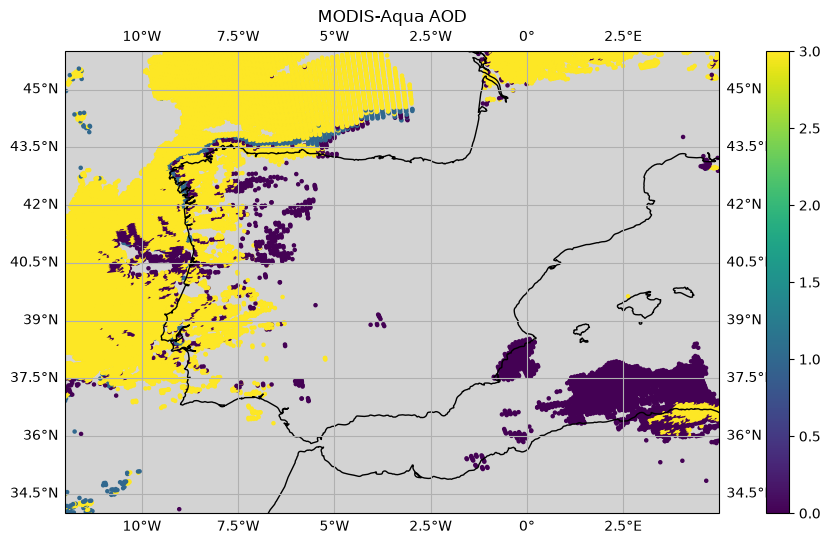

In [381]:
# Create a figure layout with a specific map projection
plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
plt.subplots_adjust(wspace=0.55)  # Adjust space between subplots

sc = ax.scatter(
    regional_aod["longitude"],
    regional_aod["latitude"],
    c=regional_aod["aod"],
    s=5,
    cmap="viridis"
)

# Add basic map features
ax.coastlines()
#ax.stock_img()  # Adds a basic color topography background
ax.gridlines(draw_labels=True)  # Add gridlines with labels

ax.set_xlim(-12, 5)
ax.set_ylim(34, 46)
ax.set_facecolor("lightgray")

cbar = fig.colorbar(
    sc,
    orientation="vertical",
)

plt.title('MODIS-Aqua AOD')
plt.show()